   Julian_Date     Mag  Mag_Error
0   5265.81251  12.597      0.005
1   5266.79609  12.595      0.005
2   5267.78687  12.626      0.005
3   5268.82630  12.653      0.005
4   5269.77248  12.664      0.005


/tmp/ipykernel_15678/734646010.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


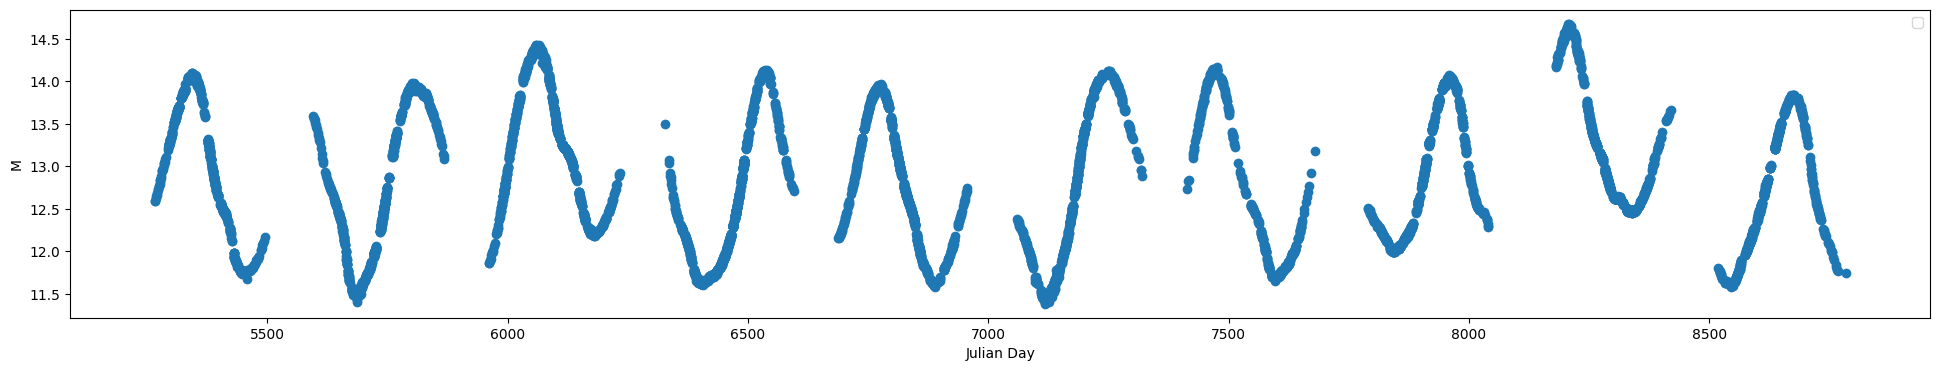

In [3]:
import astropy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("OGLE-BLG-LPV-013542.dat", 
                 sep=r'\s+', 
                 header=None, 
                 names=["Julian_Date", "Mag", "Mag_Error"],
                 usecols=[0, 1, 2])

print(df.head())

#df = df[["Julian_Date","Mag","Mag_Error"]]
plt.figure(figsize=(24,4))
plt.scatter(df["Julian_Date"], df["Mag"])
plt.xlabel('Julian Day')
plt.ylabel('M')
plt.legend()
plt.show()

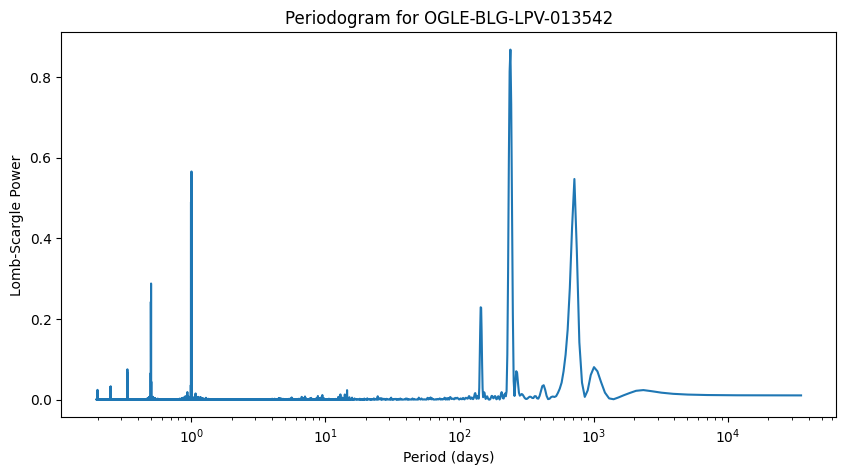

0.004178865851600581
239.29937823129256


In [4]:
#Lomb Scarge

from astropy.timeseries import LombScargle

T = df["Julian_Date"].values

M = df["Mag"].values

M_err = df["Mag_Error"].values

frequency, power = LombScargle(T,M,M_err).autopower()

best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

plt.figure(figsize=(10, 5))
plt.plot(1/frequency, power) # Graficamos Periodo en el eje X
plt.xscale('log')            # Escala logarítmica para ver mejor los periodos largos
plt.xlabel('Period (days)')
plt.ylabel('Lomb-Scargle Power')
plt.title('Periodogram for OGLE-BLG-LPV-013542')
plt.show()

print(best_frequency)
print(best_period)


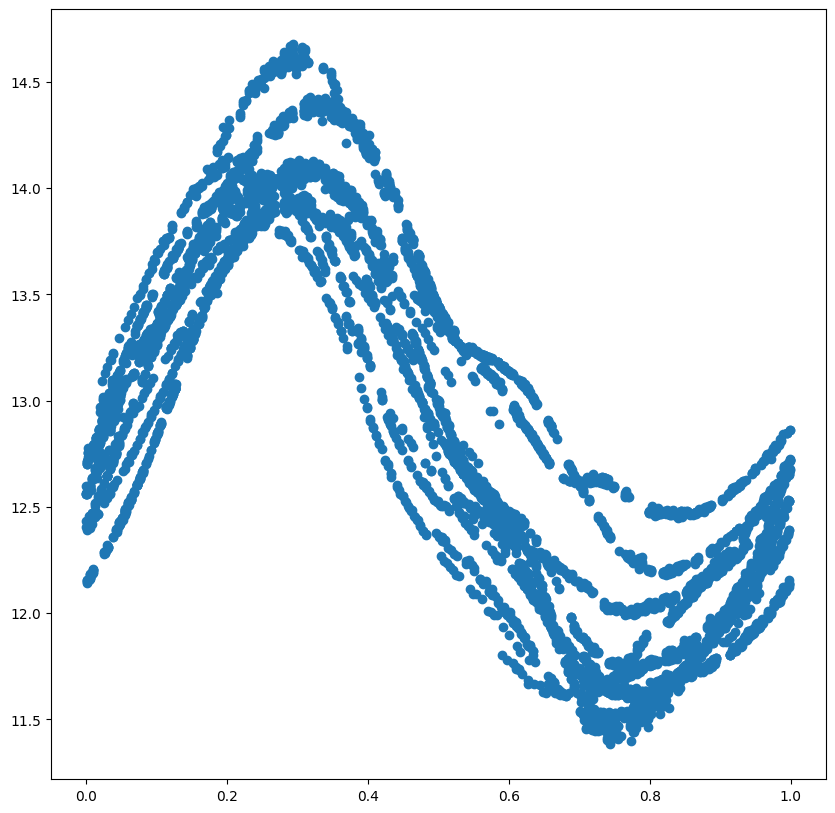

In [5]:
phi = ((T - T[0])/best_period) % 1

plt.figure(figsize=(10,10))
plt.scatter(phi,M)
plt.show()

In [6]:
from toolz import itertoolz as tz
class FourierSeries:
    def __init__(self,n_terms=None,base_freq=None,custom_freqs=None):
        """Represents the b0 + Σₙ [ Aₙ cos(2πfₙt) + Bₙ sin(2πfₙt) ] series. 
        If initialized with only `n_terms`, the `base_freq` is assumed to be 1.0. 
        fₙ = n*base_freq, unless `custom_freqs` is provided, which is used to extract the fₙ.
        If both `custom_freqs` and `n_terms` are specified, the first n elements are used.
        If none are specified, the series will have one term by default.
        """
        self.fitted = False

        if custom_freqs is not None:
            if n_terms is None:
                n_terms = len(custom_freqs)
            self._freqs = np.array(custom_freqs[:n_terms])
        else:
            if n_terms is None:
                n_terms = 1
            if base_freq is None:
                base_freq = 1.0
            self._freqs = np.array([(i+1)*base_freq for i in range(n_terms)])
        self.n_terms = n_terms
        self._raw_coef = np.zeros(1+2*n_terms)
        self._param_names = ["base"] + list(tz.interleave((
            [f"A_{i+1}" for i in range(n_terms)],
            [f"B_{i+1}" for i in range(n_terms)]
        )))
    
    def __repr__(self):
        return f"<FourierSeries with {self.n_terms} terms>\nfitted: {self.fitted}\nparameters:\n" + self.parameters.to_string()
    
    def _design_matrix(self,ts):
        ts = np.array(ts)
        N = len(ts)
        const = np.ones(N)
        SIN = np.sin(2*np.pi*self._freqs[:,None]*ts[None,:])
        COS = np.cos(2*np.pi*self._freqs[:,None]*ts[None,:])
        return np.vstack([const] + list(tz.interleave([SIN,COS]))).T
        
    def __call__(self,t):
        scalar = np.isscalar(t)
        T = np.atleast_1d(t)
        X = self._design_matrix(T)
        return X @ self._raw_coef
    
    @property
    def parameters(self):
        return pd.Series(self._raw_coef,index=self._param_names)

    @property
    def A_n(self):
        return self._raw_coef[1::2]

    @property
    def B_n(self):
        return self._raw_coef[2::2]
        
        
    def fit(self,xdata,ydata,weights=None):
        """Performs OLS fit on the given data, which must be free of NaNs and infinite values.
        This instance is given the fitted parameters and the covariance matrix
        """
        X = self._design_matrix(xdata)
        self._raw_coef = np.linalg.pinv(X) @ ydata
        response = X @ self._raw_coef
        self.fitted = True
        return ydata - response

/tmp/ipykernel_15678/3784649689.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


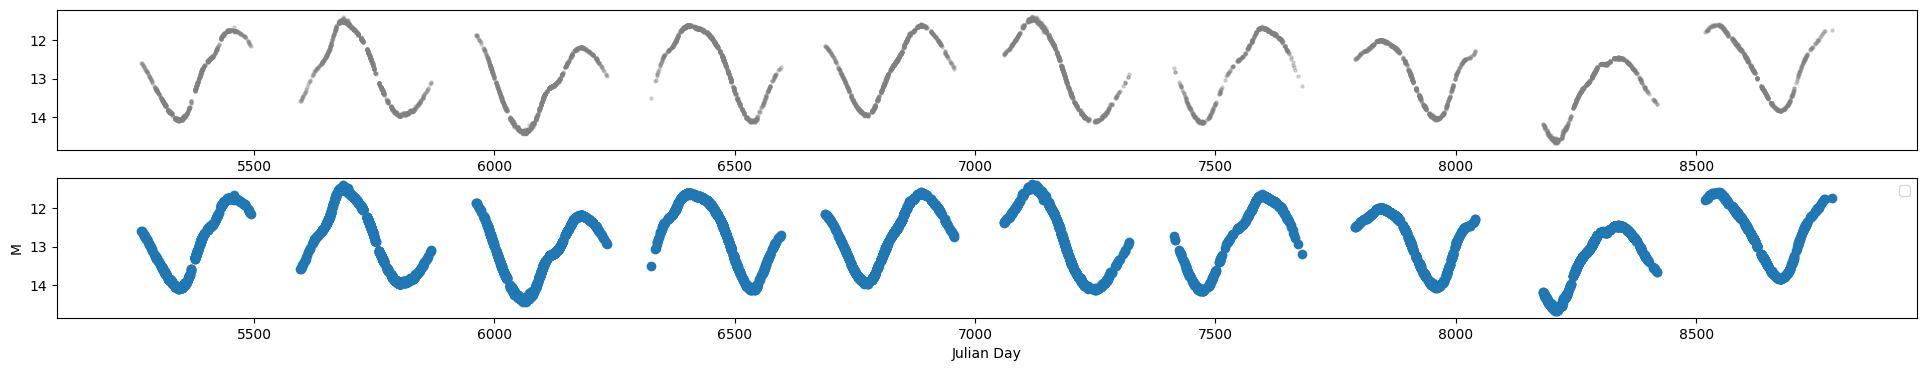

In [14]:
#find the maximum period

T_max = np.argmax(T)

f_min = 1 / best_period

fourier = FourierSeries(n_terms=9,base_freq=f_min)

t_smooth = np.linspace(T.min(),T.max(),2000)
y_fit = fourier(t_smooth)

fig, axes=plt.subplots(2,1,figsize=(24,4))
axes[0].scatter(T, M, s=5, color='gray', alpha=0.3, label='Datos OGLE')
axes[0].invert_yaxis() # Imprescindible para magnitudes astronómicas

axes[1].scatter(df["Julian_Date"], df["Mag"])
axes[1].set_xlabel('Julian Day')
axes[1].set_ylabel('M')
axes[1].invert_yaxis()
axes[1].legend()

plt.show()